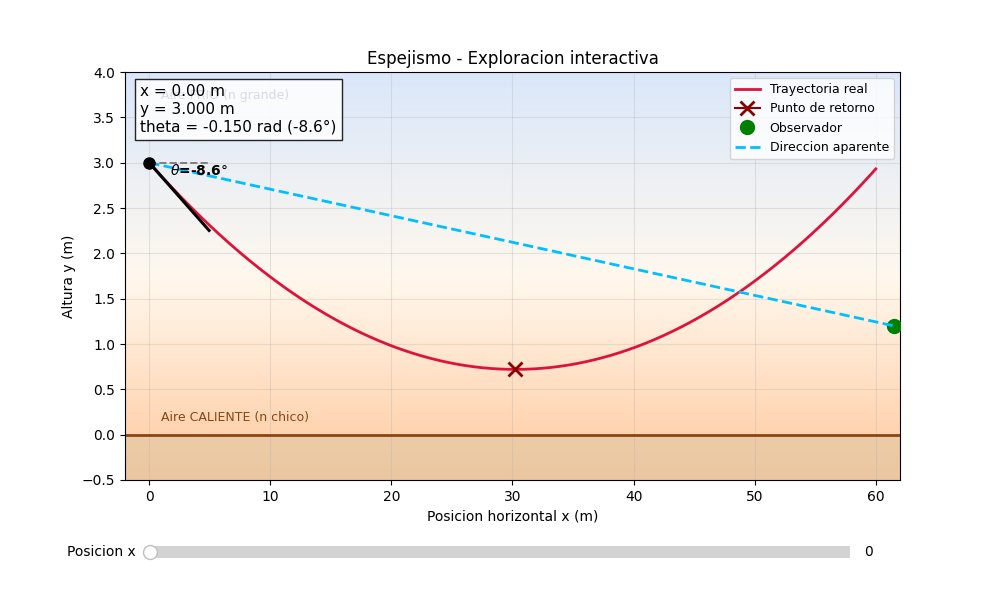

In [2]:
# ============================================================
# VISUALIZACION INTERACTIVA DEL ESPEJISMO
# Control mediante Slider, con angulo local visible
# ============================================================
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------
# CARGAR RESULTADOS DEL RK4
# ------------------------------------------------------------
datos = np.load("resultados_rk4.npz")
x_vals = datos["x"]
y_vals = datos["y"]
theta_vals = datos["theta"]
x_retorno = float(datos["x_retorno"])
y_min_sim = float(datos["y_min_sim"])
y0 = float(datos["y0"])

# ------------------------------------------------------------
# CREAR FIGURA
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(bottom=0.20)
ax.set_title("Espejismo - Exploracion interactiva")
ax.set_xlabel("Posicion horizontal x (m)")
ax.set_ylabel("Altura y (m)")
y_min_plot, y_max_plot = -0.5, y0 + 1
ax.set_xlim(x_vals.min()-2, x_vals.max()+2)
ax.set_ylim(y_min_plot, y_max_plot)
ax.grid(alpha=0.3)

# ------------------------------------------------------------
# FONDO: GRADIENTE DE AIRE CALIENTE (abajo) -> FRIO (arriba)
# ------------------------------------------------------------
cmap_aire = LinearSegmentedColormap.from_list(
    "aire", ["#ff9d4d", "#fff3e0", "#bcd4f7"]
)
gradiente = np.linspace(0, 1, 256).reshape(-1, 1)
ax.imshow(gradiente, extent=[x_vals.min()-2, x_vals.max()+2, y_min_plot, y_max_plot],
        origin="lower", aspect="auto", cmap=cmap_aire, alpha=0.55, zorder=0)
ax.text(1, 0.15, "Aire CALIENTE (n chico)", fontsize=9, color="saddlebrown")
ax.text(1, y_max_plot-0.3, "Aire FRIO (n grande)", fontsize=9, color="navy")

ax.axhspan(y_min_plot, 0, color="#d9c6a3", alpha=0.5, zorder=1)
ax.axhline(0, color="saddlebrown", linewidth=2, zorder=2)

# ------------------------------------------------------------
# TRAYECTORIA REAL
# ------------------------------------------------------------
ax.plot(x_vals, y_vals, color="crimson", linewidth=2, zorder=3,
        label="Trayectoria real")

# ------------------------------------------------------------
# PUNTO DE RETORNO
# ------------------------------------------------------------
ax.plot(x_retorno, y_min_sim, marker="x", markersize=10, markeredgewidth=2,
        color="darkred", zorder=4, label="Punto de retorno")

# ------------------------------------------------------------
# OBSERVADOR
# ------------------------------------------------------------
x_observador = x_vals.max() + 1.5
y_observador = 1.2
ax.plot(x_observador, y_observador, "o", color="green", markersize=10,
        zorder=4, label="Observador")

# ------------------------------------------------------------
# PUNTO MOVIL (la posicion actual del rayo, controlada por el slider)
# ------------------------------------------------------------
punto_rayo, = ax.plot([], [], "o", color="black", markersize=8, zorder=6)

# ------------------------------------------------------------
# LINEA APARENTE (hacia el observador, lo que el ojo "cree" ver)
# ------------------------------------------------------------
linea_aparente, = ax.plot([], [], "--", linewidth=2, color="deepskyblue",
                           zorder=5, label="Direccion aparente")

# ------------------------------------------------------------
# INDICADOR DE ANGULO LOCAL (igual que en DD2_Espejo.ipynb):
#   - linea punteada gris = referencia horizontal (theta = 0)
#   - linea solida negra  = direccion real del rayo (theta actual)
# ------------------------------------------------------------
linea_ref_angulo, = ax.plot([], [], "--", color="gray", linewidth=1.4, zorder=5)
linea_dir_angulo, = ax.plot([], [], color="black", linewidth=2.2, zorder=6)
texto_angulo = ax.annotate("", xy=(0, 0), fontsize=10, fontweight="bold",
                            color="black", zorder=7)

# ------------------------------------------------------------
# TEXTO DE INFORMACION (x, y, theta)
# ------------------------------------------------------------
texto = ax.text(0.02, 0.97, "", transform=ax.transAxes, va="top", fontsize=11,
                 bbox=dict(facecolor="white", alpha=0.85))

ax.legend(loc="upper right", fontsize=9)

# ------------------------------------------------------------
# SLIDER
# ------------------------------------------------------------
ax_slider = plt.axes([0.15, 0.06, 0.70, 0.04])
slider = Slider(
    ax=ax_slider,
    label="Posicion x",
    valmin=float(x_vals.min()),
    valmax=float(x_vals.max()),
    valinit=float(x_vals.min()),
)

# ------------------------------------------------------------
# FUNCION DE ACTUALIZACION (se ejecuta cada vez que movés el slider)
# ------------------------------------------------------------
LARGO_ANGULO = 5.0  # largo de las lineas del indicador de angulo, en metros

def actualizar(valor):
    indice = np.argmin(np.abs(x_vals - valor))
    x = x_vals[indice]
    y = y_vals[indice]
    theta = theta_vals[indice]
    theta_deg = np.degrees(theta)

    # --- punto movil ---
    punto_rayo.set_data([x], [y])

    # --- linea aparente hacia el observador ---
    linea_aparente.set_data([x, x_observador], [y, y_observador])

    # --- indicador de angulo: referencia horizontal + direccion real ---
    linea_ref_angulo.set_data([x, x+LARGO_ANGULO], [y, y])
    linea_dir_angulo.set_data([x, x+LARGO_ANGULO*np.cos(theta)],
                            [y, y+LARGO_ANGULO*np.sin(theta)])

    # etiqueta theta=..° en el hueco entre las dos rectas (sobre la bisectriz)
    r_etiqueta = LARGO_ANGULO * 0.35
    angulo_bisectriz = theta / 2
    texto_angulo.set_text(rf"$\theta$={theta_deg:.1f}$\degree$")
    texto_angulo.set_position((x + r_etiqueta*np.cos(angulo_bisectriz),
                                y + r_etiqueta*np.sin(angulo_bisectriz)))

    # --- texto de informacion general ---
    texto.set_text(
        f"x = {x:.2f} m\n"
        f"y = {y:.3f} m\n"
        f"theta = {theta:.3f} rad ({theta_deg:.1f}°)"
    )

    fig.canvas.draw_idle()

# ------------------------------------------------------------
# CONECTAR EL SLIDER
# ------------------------------------------------------------
slider.on_changed(actualizar)

# ------------------------------------------------------------
# ESTADO INICIAL
# ------------------------------------------------------------
actualizar(float(x_vals[0]))
plt.show()